In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import random

In [3]:
# 1. Load the monolithic compiled TensorDataset from disk
# Note: Since it's 5.5GB, this might take 5-10 seconds to read into RAM
print("Loading TensorDataset into memory from disk...")
raw_tensor_dataset = torch.load("torch_sliding_dataset.pt", weights_only=False)
print("✓ Loaded Data successfully.")

Loading TensorDataset into memory from disk...
✓ Loaded Data successfully.


In [4]:
# 2. Wrapping it to enable dynamic spatial augmentations
class AugmentedLandsatDataset(Dataset):
    def __init__(self, tensor_dataset):
        self.dataset = tensor_dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        # Retrieve the static patch from RAM
        x, y = self.dataset[idx]
        
        # ==============================================================
        # DYNAMIC SPATIAL AUGMENTATIONS
        # Important: You must apply identical spatial transforms to BOTH 
        # the satellite image (x) and the ground truth labels (y)
        # ==============================================================
        
        # Random Horizontal Flip (50% chance)
        if random.random() > 0.5:
            x = TF.hflip(x)
            y = TF.hflip(y)
            
        # Random Vertical Flip (50% chance)
        if random.random() > 0.5:
            x = TF.vflip(x)
            y = TF.vflip(y)
            
        # Additional transformations (color jitter, etc) can go here on `x` ONLY
            
        return x, y

In [ ]:
# 3. Instantiate the Augmented Dataset
train_dataset = AugmentedLandsatDataset(raw_tensor_dataset)

# 4. Standard PyTorch DataLoader
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,        # Set batch size depending on your VRAM
    shuffle=True,         # Extremely important to randomize patches
    num_workers=4,        # Use CPU multiprocessing to load data quickly
    pin_memory=True       # Faster host-to-GPU transfer
)




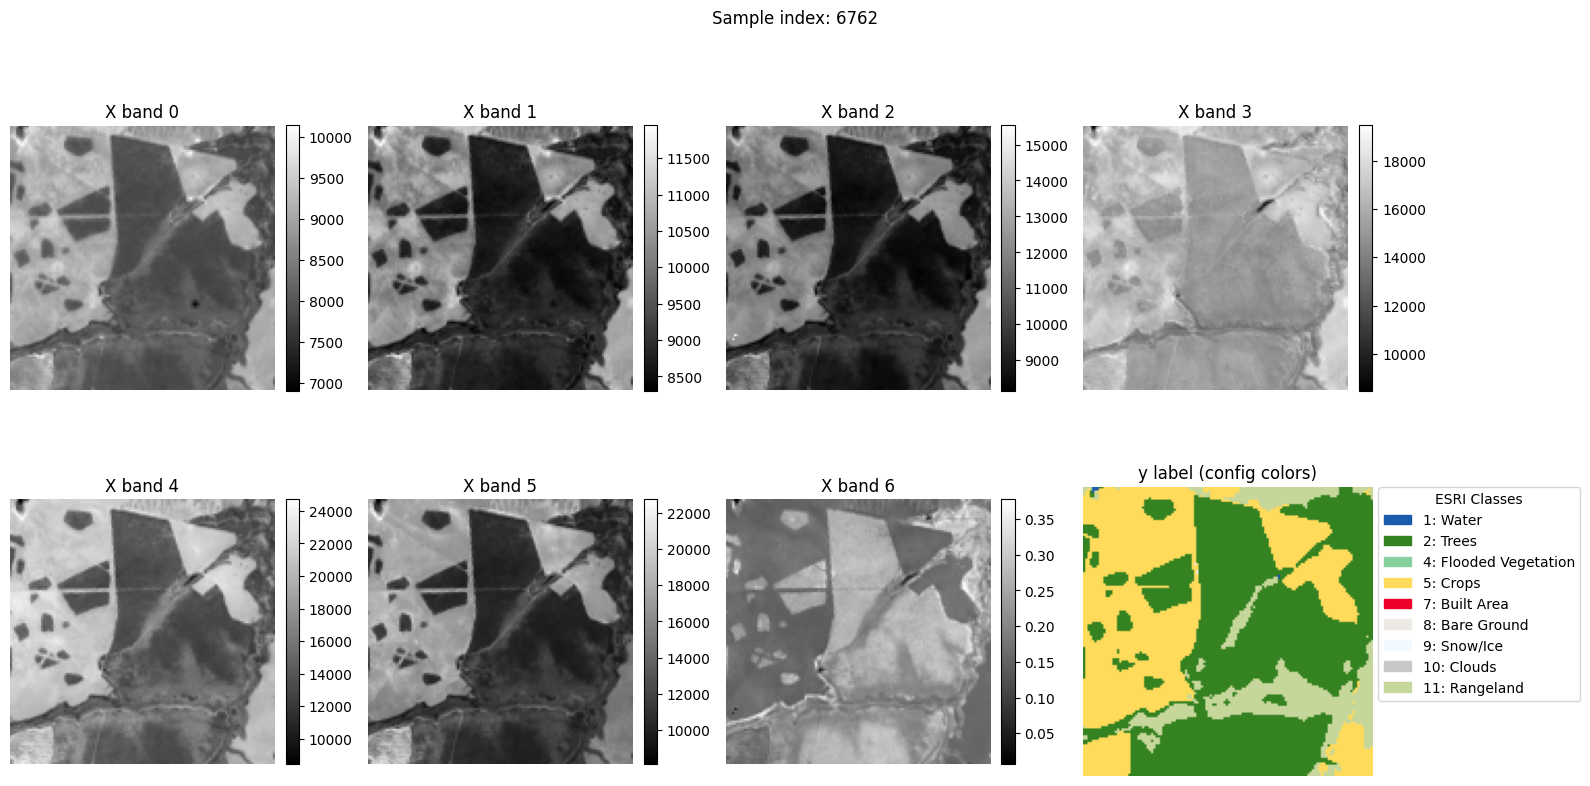

sample_idx=6762, X shape=(7, 128, 128), y shape=(1, 128, 128)


In [14]:
from pathlib import Path
import sys
import math
import random
import importlib.util

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
import torch


def load_config_module():
    # 1) Try standard import first.
    try:
        import config as cfg
        return cfg
    except ModuleNotFoundError:
        pass

    # 2) Probe common workspace-relative locations.
    candidates = [
        Path.cwd() / "config.py",
        Path.cwd() / "work" / "landsat_download" / "config.py",
        Path.cwd() / "landsat_download" / "config.py",
        Path.cwd().parent / "config.py",
        Path.cwd().parent / "landsat_download" / "config.py",
        Path.cwd().parent.parent / "landsat_download" / "config.py",
    ]

    cfg_path = next((p for p in candidates if p.exists()), None)

    # 3) Fallback: search upward for a sibling folder containing landsat_download/config.py.
    if cfg_path is None:
        for parent in [Path.cwd()] + list(Path.cwd().parents):
            probe = parent / "work" / "landsat_download" / "config.py"
            if probe.exists():
                cfg_path = probe
                break

    if cfg_path is None:
        raise ModuleNotFoundError("Could not locate config.py; cannot apply ESRI color mapping")

    spec = importlib.util.spec_from_file_location("config", cfg_path)
    cfg = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(cfg)
    return cfg


config = load_config_module()

# Load dataset if not already loaded in the current kernel.
if "raw_tensor_dataset" not in globals():
    path_candidates = [
        Path("torch_sliding_dataset.pt"),
        Path("../torch_sliding_dataset.pt"),
        Path("../big_data/dataset/torch_sliding_dataset.pt"),
        Path("work/landsat_download/torch_sliding_dataset.pt"),
        Path("work/landsat_download/big_data/dataset/torch_sliding_dataset.pt"),
    ]
    dataset_path = next((p for p in path_candidates if p.exists()), None)
    if dataset_path is None:
        raise FileNotFoundError("Could not find torch_sliding_dataset.pt in expected locations")
    raw_tensor_dataset = torch.load(dataset_path, weights_only=False)

sample_idx = random.randrange(len(raw_tensor_dataset))
x, y = raw_tensor_dataset[sample_idx]

x_np = x.detach().cpu().numpy()
y_np = y.detach().cpu().numpy() if torch.is_tensor(y) else np.asarray(y)
if y_np.ndim == 3 and y_np.shape[0] == 1:
    y_np = y_np[0]

n_bands = x_np.shape[0]
n_panels = n_bands + 1  # +1 for y
n_cols = min(4, n_panels)
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.atleast_1d(axes).ravel()

for band_idx in range(n_bands):
    im = axes[band_idx].imshow(x_np[band_idx], cmap="gray")
    axes[band_idx].set_title(f"X band {band_idx}")
    axes[band_idx].axis("off")
    plt.colorbar(im, ax=axes[band_idx], fraction=0.046, pad=0.04)

# Always use config-based ESRI colormap for y.
max_class = max(config.ESRI_CLASSES.keys())
color_list = ["#000000"] * (max_class + 1)
for class_id, (_, hex_color) in config.ESRI_CLASSES.items():
    color_list[class_id] = hex_color
cmap = ListedColormap(color_list)
norm = BoundaryNorm(np.arange(-0.5, max_class + 1.5, 1), cmap.N)

label_ax = axes[n_bands]
label_ax.imshow(y_np, cmap=cmap, norm=norm)
label_ax.set_title("y label (config colors)")
label_ax.axis("off")

legend_patches = [
    mpatches.Patch(color=hex_color, label=f"{class_id}: {name}")
    for class_id, (name, hex_color) in sorted(config.ESRI_CLASSES.items())
    if class_id != 0
]
label_ax.legend(
    handles=legend_patches,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0.0,
    title="ESRI Classes",
)

for i in range(n_panels, len(axes)):
    axes[i].axis("off")

plt.suptitle(f"Sample index: {sample_idx}", y=1.02)
plt.tight_layout()
plt.show()

print(f"sample_idx={sample_idx}, X shape={tuple(x.shape)}, y shape={tuple(y.shape)}")

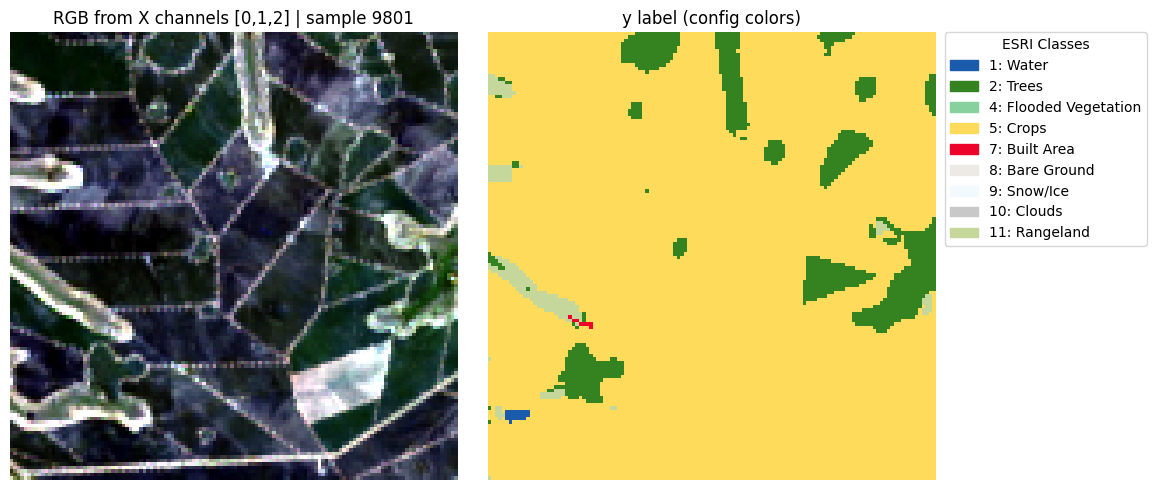

sample_idx=9801, X shape=(7, 128, 128), y shape=(1, 128, 128)


In [6]:
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
import torch


def stretch_percentile(channel: np.ndarray, low: float = 2.0, high: float = 98.0) -> np.ndarray:
    channel = channel.astype(np.float32)
    p_low, p_high = np.percentile(channel, [low, high])
    if p_high <= p_low:
        return np.zeros_like(channel, dtype=np.float32)
    return np.clip((channel - p_low) / (p_high - p_low), 0, 1)


# Ensure config is available (reuse helper if already defined).
if "config" not in globals():
    if "load_config_module" in globals():
        config = load_config_module()
    else:
        import importlib.util

        candidates = [
            Path.cwd() / "config.py",
            Path.cwd() / "work" / "landsat_download" / "config.py",
            Path.cwd().parent / "config.py",
            Path.cwd().parent.parent / "landsat_download" / "config.py",
        ]
        cfg_path = next((p for p in candidates if p.exists()), None)
        if cfg_path is None:
            raise ModuleNotFoundError("Could not locate config.py for ESRI color mapping")
        spec = importlib.util.spec_from_file_location("config", cfg_path)
        config = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(config)

# Ensure dataset is loaded.
if "raw_tensor_dataset" not in globals():
    path_candidates = [
        Path("torch_sliding_dataset.pt"),
        Path("../torch_sliding_dataset.pt"),
        Path("../big_data/dataset/torch_sliding_dataset.pt"),
        Path("work/landsat_download/torch_sliding_dataset.pt"),
        Path("work/landsat_download/big_data/dataset/torch_sliding_dataset.pt"),
    ]
    dataset_path = next((p for p in path_candidates if p.exists()), None)
    if dataset_path is None:
        raise FileNotFoundError("Could not find torch_sliding_dataset.pt in expected locations")
    raw_tensor_dataset = torch.load(dataset_path, weights_only=False)

sample_idx = random.randrange(len(raw_tensor_dataset))
x, y = raw_tensor_dataset[sample_idx]

x_np = x.detach().cpu().numpy()
y_np = y.detach().cpu().numpy() if torch.is_tensor(y) else np.asarray(y)
if y_np.ndim == 3 and y_np.shape[0] == 1:
    y_np = y_np[0]

if x_np.shape[0] < 3:
    raise ValueError(f"Need at least 3 channels for RGB, got {x_np.shape[0]}")

# As requested: RGB from channels [0, 1, 2]
rgb = np.dstack([
    stretch_percentile(x_np[2]),
    stretch_percentile(x_np[1]),
    stretch_percentile(x_np[0]),
])

max_class = max(config.ESRI_CLASSES.keys())
color_list = ["#000000"] * (max_class + 1)
for class_id, (_, hex_color) in config.ESRI_CLASSES.items():
    color_list[class_id] = hex_color
cmap = ListedColormap(color_list)
norm = BoundaryNorm(np.arange(-0.5, max_class + 1.5, 1), cmap.N)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(rgb)
axes[0].set_title(f"RGB from X channels [0,1,2] | sample {sample_idx}")
axes[0].axis("off")

axes[1].imshow(y_np, cmap=cmap, norm=norm)
axes[1].set_title("y label (config colors)")
axes[1].axis("off")

legend_patches = [
    mpatches.Patch(color=hex_color, label=f"{class_id}: {name}")
    for class_id, (name, hex_color) in sorted(config.ESRI_CLASSES.items())
    if class_id != 0
]
axes[1].legend(
    handles=legend_patches,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0.0,
    title="ESRI Classes",
)

plt.tight_layout()
plt.show()
print(f"sample_idx={sample_idx}, X shape={tuple(x.shape)}, y shape={tuple(y.shape)}")